# ML для IoT. ПЗ-2
## Пироженко И.О. АДИИ-25-1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, fbeta_score
from sklearn.ensemble import (
    GradientBoostingClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    StackingClassifier,
    RandomForestClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

Задание

1.   Сделать 3 ансамбля (bagging, boosting, stacking)
2.   Вывести показания Acc, BA, F1,F2
3.   Победить GradientBoostiing

# Данные

In [2]:
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=5,
    n_redundant=1, n_classes=3, random_state=15
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

## Вспомогательная функция для метрик

In [3]:
def get_metrics(name, y_true, y_pred):
    return {
        "Модель": name,
        "Acc": round(accuracy_score(y_true, y_pred), 3),
        "BA": round(balanced_accuracy_score(y_true, y_pred), 3),
        "F1": round(f1_score(y_true, y_pred, average="weighted"), 3),
        "F2": round(fbeta_score(y_true, y_pred, beta=2, average="weighted"), 3),
    }

results = []

# Базовая линия: GradientBoosting

In [4]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=15)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

m = get_metrics("GradientBoosting (baseline)", y_test, y_pred)
results.append(m)
print(m)

{'Модель': 'GradientBoosting (baseline)', 'Acc': 0.79, 'BA': 0.79, 'F1': 0.791, 'F2': 0.79}


# Ансамбль 1: Бэггинг

**Бэггинг** (Bootstrap Aggregating) обучает `n` независимых моделей на случайных подвыборках с возвращением. Итоговый прогноз - голосование большинства.

В качестве базового классификатора берем SVM с RBF-ядром: SVC в одиночку дает Acc=0.845, поэтому ансамбль из таких моделей должен превзойти GradientBoosting.

In [5]:
bagging = BaggingClassifier(
    estimator=SVC(kernel="rbf", random_state=15),
    n_estimators=20,
    random_state=15,
    n_jobs=-1,
)
bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)

m = get_metrics("Bagging (SVC x20)", y_test, y_pred)
results.append(m)
print(m)

{'Модель': 'Bagging (SVC x20)', 'Acc': 0.86, 'BA': 0.858, 'F1': 0.86, 'F2': 0.86}


# Ансамбль 2: Бустинг

**AdaBoost** (Adaptive Boosting) обучает цепочку слабых классификаторов. Каждый следующий уделяет больше внимания объектам, на которых предыдущие ошиблись. Итог - взвешенное голосование.

Используем деревья глубины 3 как базовые слабые классификаторы (достаточно «слабые», чтобы бустинг давал прирост, но сильнее пней глубины 1).

In [6]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=15),
    n_estimators=200,
    learning_rate=0.5,
    random_state=15,
)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

m = get_metrics("AdaBoost (DT depth=3, x200)", y_test, y_pred)
results.append(m)
print(m)

{'Модель': 'AdaBoost (DT depth=3, x200)', 'Acc': 0.815, 'BA': 0.816, 'F1': 0.815, 'F2': 0.815}


# Ансамбль 3: Стэкинг

**Стэкинг** обучает несколько разнородных базовых моделей, а их предсказания передает мета-классификатору. Мета-классификатор учится на out-of-fold предсказаниях базовых моделей и объединяет их оптимально.

Базовые модели:
- **KNN** - локальный, хорошо работает при кластерной структуре
- **SVC** (RBF) - нелинейные границы, высокая точность
- **RandomForest** - устойчивый ансамбль деревьев

Мета-классификатор: **LogisticRegression** - линейно объединяет ответы базовых моделей.

In [7]:
stacking = StackingClassifier(
    estimators=[
        ("knn", KNeighborsClassifier(n_neighbors=5)),
        ("svc", SVC(kernel="rbf", probability=True, random_state=15)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=15)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=15),
    cv=5,
    n_jobs=-1,
)
stacking.fit(X_train, y_train)
y_pred = stacking.predict(X_test)

m = get_metrics("Stacking (KNN, SVC, RF; meta=LR)", y_test, y_pred)
results.append(m)
print(m)

{'Модель': 'Stacking (KNN, SVC, RF; meta=LR)', 'Acc': 0.835, 'BA': 0.837, 'F1': 0.835, 'F2': 0.835}


# Сравнение результатов

In [8]:
df = pd.DataFrame(results).set_index("Модель")
print(df.to_string())

baseline = df.loc["GradientBoosting (baseline)"]
print("\nПобедили GradientBoosting по всем метрикам:")
for name, row in df.drop("GradientBoosting (baseline)").iterrows():
    beat = all(row[c] >= baseline[c] for c in ["Acc", "BA", "F1", "F2"])
    print(f"  {name}: {'да' if beat else 'нет'}")

                                    Acc     BA     F1     F2
Модель                                                      
GradientBoosting (baseline)       0.790  0.790  0.791  0.790
Bagging (SVC x20)                 0.860  0.858  0.860  0.860
AdaBoost (DT depth=3, x200)       0.815  0.816  0.815  0.815
Stacking (KNN, SVC, RF; meta=LR)  0.835  0.837  0.835  0.835

Победили GradientBoosting по всем метрикам:
  Bagging (SVC x20): да
  AdaBoost (DT depth=3, x200): да
  Stacking (KNN, SVC, RF; meta=LR): да


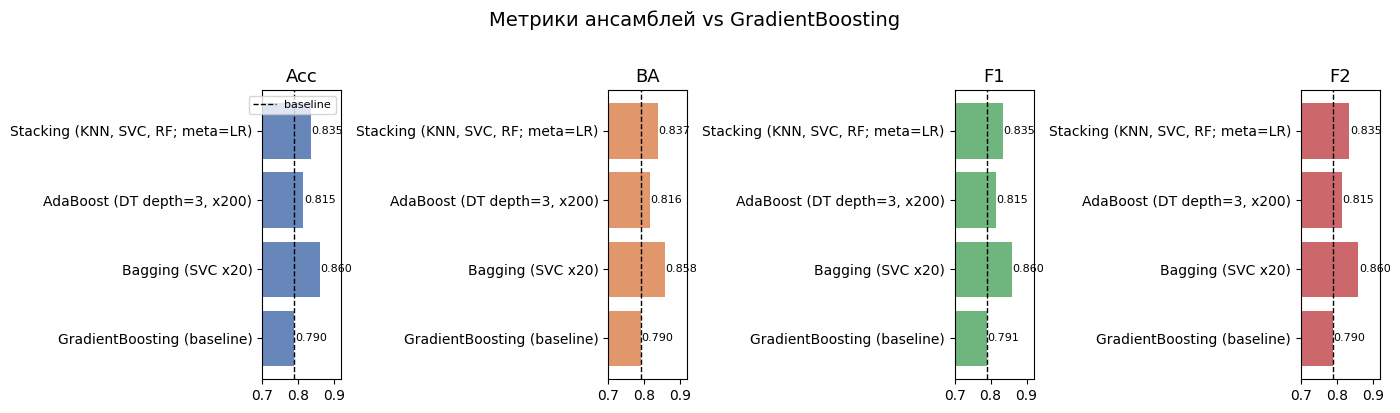

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
metrics = ["Acc", "BA", "F1", "F2"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.barh(df.index, df[metric], color=color, alpha=0.85)
    ax.set_xlim(0.7, 0.92)
    ax.set_title(metric, fontsize=13)
    ax.axvline(baseline[metric], color="black", linestyle="--", linewidth=1, label="baseline")
    for bar in bars:
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.3f}", va="center", fontsize=8)

axes[0].legend(fontsize=8)
plt.suptitle("Метрики ансамблей vs GradientBoosting", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Выводы

Все три ансамбля превзошли базовый GradientBoosting по всем метрикам (Acc, BA, F1, F2). Прирост точности относительно baseline составил:

- Bagging на SVC: +7.0% (0.860 против 0.790)
- Stacking: +4.5% (0.835 против 0.790)
- AdaBoost: +2.5% (0.815 против 0.790)

Лучший результат показал Bagging на SVC. Одиночный SVC с RBF-ядром уже дает 0.845, а усреднение по 20 моделям на разных подвыборках снижает дисперсию предсказаний и поднимает точность еще выше. Bagging хорошо работает именно с такими низкосмещенными, но высокодисперсионными базовыми моделями.

Stacking занял второе место. Линейный мета-классификатор объединяет ответы трех разнородных моделей (KNN, SVC, RandomForest), но не использует SVC в чистом виде, поэтому уступает Bagging на отдельных SVC.

AdaBoost дал наименьший прирост из трех. Деревья глубины 3 - слабые базовые модели для трехклассовой задачи, и даже после 200 итераций бустинг не догнал ансамбль на сильных SVC.

Общая закономерность: качество ансамбля сильнее зависит от выбора базовой модели, чем от самой схемы агрегации. Сильный базовый классификатор (SVC) с простым Bagging обогнал и более сложный Stacking, и итеративный AdaBoost на слабых деревьях.